In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import StackingClassifier,RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
nltk.download('punkt')
nltk.download('stopwords')


import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anujs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anujs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading data

In [160]:
df=pd.read_csv('email.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


EDA

In [161]:
df.shape

(5573, 2)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [163]:
df.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [164]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [165]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5568    False
5569    False
5570    False
5571    False
5572    False
Length: 5573, dtype: bool

In [166]:
counts=df['Category'].value_counts()
counts

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

Label encoding

In [167]:
encoder=LabelEncoder()
df['Category']=encoder.fit_transform(df['Category'])
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [168]:
df = df[df["Category"] != 2]

In [169]:
counts= df['Category'].value_counts()
counts

Category
0    4825
1     747
Name: count, dtype: int64

<Axes: xlabel='Category'>

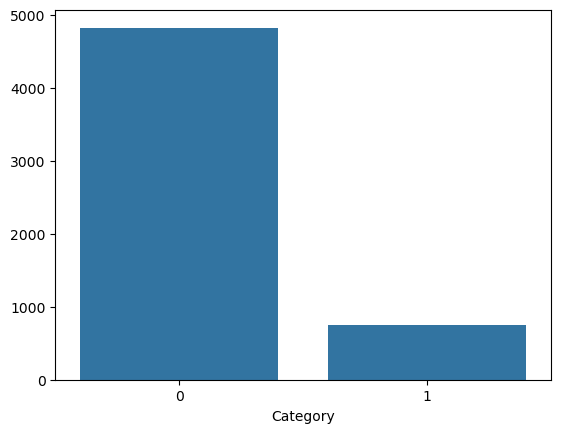

In [170]:
sns.barplot(x=counts.index,y=counts.values)

In [171]:
message= df['Message']
message

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: object

In [172]:
stop_words= set(stopwords.words('english'))
lemmatizer= WordNetLemmatizer()

def preprecess_text(txt):
    txt=str(txt).lower()
    
    txt= re.sub(r'[^a-zA-Z\s]','',txt)
    
    words= txt.split()
    
    words= [word for word in words if word not in stop_words]
    
    words= [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

message= message.apply(preprecess_text)

In [173]:
message.head()

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4             nah dont think go usf life around though
Name: Message, dtype: object

In [174]:
tfidf=TfidfVectorizer()
X= tfidf.fit_transform(message)
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 45375 stored elements and shape (5572, 7950)>

In [175]:
print(f"Vacabulary: {tfidf.get_feature_names_out()}")
print(f"\nBow matrix: {X.toarray()}")

Vacabulary: ['aa' 'aah' 'aaniye' ... 'zoom' 'zouk' 'zyada']

Bow matrix: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [176]:
y=df['Category']

Train test split

In [177]:
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=42,test_size=0.2)

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

lr = LogisticRegression(max_iter=1000)

param_dist = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

random_lr = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_lr.fit(X_train, y_train)

print(random_lr.best_params_)
print(random_lr.best_score_)

{'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
0.9748682641059323


In [179]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

nb = MultinomialNB()

param_dist = {
    "alpha": np.linspace(0.01, 2, 100),
    "fit_prior": [True, False]
}

random_nb = RandomizedSearchCV(
    nb,
    param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_nb.fit(X_train, y_train)

print(random_nb.best_params_)
print(random_nb.best_score_)

{'fit_prior': True, 'alpha': np.float64(0.3115151515151515)}
0.9771124297282743


In [180]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

param_dist = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "loss": ["hinge", "squared_hinge"]
}

random_svm = RandomizedSearchCV(
    svm,
    param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_svm.fit(X_train, y_train)

print(random_svm.best_params_)
print(random_svm.best_score_)

{'loss': 'squared_hinge', 'C': 10}
0.9773373999084015


In [181]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_rf = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print(random_rf.best_params_)

{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


In [182]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Initialize the model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter search space
param_dist = {
    "criterion": ["gini", "entropy", "log_loss"],
    "splitter": ["best", "random"],
    "max_depth": [None, 5, 10, 20, 30, 50, 100],
    "min_samples_split": np.arange(2, 21),
    "min_samples_leaf": np.arange(1, 11),
    "max_features": [None, "sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

# Random Search
random_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",      # Use "accuracy" if your classes are balanced
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Train
random_dt.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_dt.best_params_)
print("Best CV Score:", random_dt.best_score_)

# Best model
best_dt = random_dt.best_estimator_

# Evaluate
y_pred = best_dt.predict(X_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'splitter': 'random', 'min_samples_split': np.int64(14), 'min_samples_leaf': np.int64(2), 'max_features': None, 'max_depth': None, 'criterion': 'log_loss', 'class_weight': None}
Best CV Score: 0.808655148976178


Model tunning

In [183]:
models={
    'LR': LogisticRegression(solver='liblinear',penalty='l2',C=100),
    'Multinomial_NB': MultinomialNB(fit_prior=True,alpha=np.float64(0.3115151515151515)),
    'SVC': LinearSVC(loss='hinge',C=10,random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42,n_estimators=100,min_samples_split=10,min_samples_leaf=1,max_features='sqrt',max_depth=None),
    'DT':DecisionTreeClassifier(random_state=42,splitter='random',min_samples_split=np.int64(14),min_samples_leaf=np.int64(6),max_features='log2',max_depth=100,criterion='entropy',class_weight=None),
    'KNN': KNeighborsClassifier(metric='manhattan',n_neighbors=11,weights='distance')
}


Models evalulation

In [184]:
list=[]

for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    
    list.append({
        'Model': name,
        'Accuracy':round(accuracy_score(y_test,y_pred)*100,2),
        'Recall':round(recall_score(y_test,y_pred)*100,2),
        'F1 Score':round(f1_score(y_test,y_pred)*100,2)
    })

results_df= pd.DataFrame(list)
results_df.sort_values(by='Accuracy',ascending=False)
    
    

,Model,Accuracy,Recall,F1 Score
2,SVC,98.30,89.26,93.33
0,LR,98.21,87.92,92.91
3,RandomForest,97.94,84.56,91.64
1,Multinomial_NB,97.58,86.58,90.53
5,KNN,92.38,42.95,60.09
4,DT,87.09,4.70,8.86


Stacking

In [185]:
base_models = [
    ('DT', models['DT']),
    ('lr', models['LR']),
    ('mnb', models['Multinomial_NB'])
]

meta_model = models['KNN']

classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train
classifier.fit(X_train, y_train)

# Predict
y_pred = classifier.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

Accuracy: 98.57%


In [186]:
confusion_matrix(y_test,y_pred)

array([[961,   5],
       [ 11, 138]])

<Axes: >

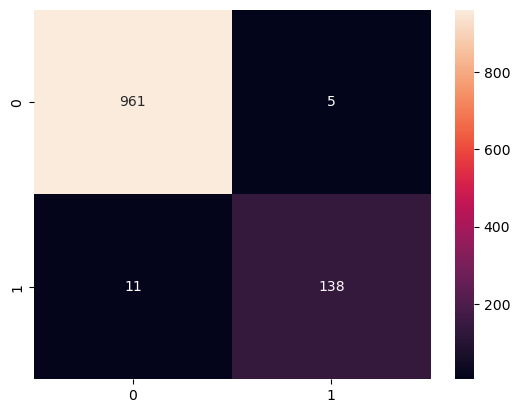

In [187]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')

Input

In [204]:
def predictor(model,tfidf, seed_text):
    # Preprocess
    seed_text = preprecess_text(seed_text)

    txt=tfidf.transform([seed_text])

    prediction = model.predict(txt)[0]

    return "ham" if prediction == 0 else "spam"


In [ ]:
text="We are pleased to inform you that your email address has been selected as the winner of our international lottery. To claim your prize, please send your full name, address, phone number, and bank details within 24 hours."
print(predictor(classifier,tfidf,text))

spam


In [208]:
text='I have attached my completed assignment for the Machine Learning course. Please let me know if there are any issues with the submission. Regards, Anuj'
print(predictor(classifier,tfidf,text))

ham
